THƯ VIỆN CẦN CÓ

In [46]:
import matplotlib.pyplot as plt
import joblib as jlb
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from pyclustering.utils import timedcall
from data_processing import D,data_before_scaling

CLASS CLARANS VÀ UTILS

In [47]:
#Class Clarans
import numpy as np
class CLARANS:
    def __init__(self,data,n_clusters,num_local,max_neighbors):
        self.data=data
        self.n_clusters=n_clusters
        self.num_local=num_local
        self.max_neighbors=max_neighbors
        self.labels=None
        self.medoids=None
        self.sihouette_score_=None

    def _euclid_dist(self,X,medoids):
        return  np.linalg.norm(X[:, np.newaxis] -medoids,axis=2)
    def _compute_total_cost(self,X,medoids):
        distances=self._euclid_dist(X,medoids)
        return np.sum(np.min(distances,axis=1))
    def fit(self):
        X=self.data.values
        best_cost=float('inf')

        for _ in range(self.num_local):
            medoids_idx=np.random.choice(len(X),self.n_clusters,replace=False)
            medoids=X[medoids_idx]

            current_cost=self._compute_total_cost(X,medoids)
            neighbor=0
            while neighbor<self.max_neighbors:
                medoids_random_pos=np.random.randint(self.n_clusters)
                candidate_idx = np.random.randint(len(X))
                while candidate_idx in medoids_idx:
                    candidate_idx=np.random.randint(len(X))

                new_medoids_idx = medoids_idx.copy()
                new_medoids_idx[medoids_random_pos] = candidate_idx
                new_medoids = X[new_medoids_idx]

                new_cost=self._compute_total_cost(X,new_medoids)
                if current_cost>new_cost:
                    medoids=new_medoids
                    medoids_idx = new_medoids_idx
                    current_cost=new_cost
                    neighbor=0
                else:
                    neighbor+=1
            if current_cost<best_cost:
                best_cost=current_cost
                self.medoids=medoids
        distances=self._euclid_dist(X,self.medoids)
        self.labels=np.argmin(distances,axis=1)
        self.Inertia_=best_cost
    def get_medoids(self):
        return self.medoids
    def get_labels(self):
        return self.labels
    def get_Inertia(self):
        return self.Inertia_

def clarans_silhouette_analysis(data, k_range, num_local, max_neighbors,print_scores=False):
    silhouette_scores = []
    for k in k_range:
        model = CLARANS(data, k, num_local, max_neighbors)
        model.fit()
        model.sihouette_score_=silhouette_score(data,model.get_labels())
        silhouette_scores.append(model.sihouette_score_)
        if print_scores:
            print(f'k={k}, Silhouette Score: {model.sihouette_score_:.4f}')

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, silhouette_scores, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Analysis for CLARANS')
    plt.show()

def clarans_davies_bouldin_analysis(data, k_range, num_local, max_neighbors,print_scores=False):
    db_scores = []
    for k in k_range:
        model = CLARANS(data, k, num_local, max_neighbors)
        model.fit()
        db_score = davies_bouldin_score(data, model.get_labels())
        db_scores.append(db_score)
        if print_scores:
            print(f'k={k}, Davies-Bouldin Score: {db_score:.4f}')

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, db_scores, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Davies-Bouldin Score')
    plt.title('Davies-Bouldin Analysis for CLARANS')
    plt.show()
    
def clarans_Inertia_analysis(data, k_range, num_local, max_neighbors,print_scores=False):
    inertia_scores = []
    k_values=k_range
    for k in k_range:
        model = CLARANS(data, k, num_local, max_neighbors)
        model.fit()
        inertia = model.get_Inertia()
        inertia_scores.append(inertia)
        if print_scores:
            print(f'k={k}, Inertia: {inertia:.4f}')
    kneedle=KneeLocator(k_values,inertia_scores,curve='convex',direction='decreasing')
    k_optimal=kneedle.knee
    
    plt.figure(figsize=(8, 5))
    plt.plot(k_range, inertia_scores, marker='o')
    plt.axvline(x=k_optimal, linestyle='--')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Inertia Analysis for CLARANS')
    plt.show()

CHỌN FEATURES

In [48]:
features=['Age','Income','Education'
                ,'Family_Size','Total_Spend'
                ,'Wines','Food','Gold'
                ,'Wines_ratio','Food_ratio','Gold_ratio'
                ,'NumWebPurchases'
                ,'NumDealsPurchases','NumCatalogPurchases'
                ,'NumStorePurchases','NumWebVisitsMonth']
data=D[features].copy()
print(data.shape)
print(data.head(1))

(2229, 16)
        Age    Income  Education  Family_Size  Total_Spend     Wines  \
0  1.015715  0.316484  -0.893147    -1.759459     1.204332  0.985094   

       Food      Gold  Wines_ratio  Food_ratio  Gold_ratio  NumWebPurchases  \
0  1.420852  1.060908    -0.212241    0.713606   -0.618688         1.405471   

   NumDealsPurchases  NumCatalogPurchases  NumStorePurchases  \
0           0.358938             2.633984           -0.55916   

   NumWebVisitsMonth  
0            0.68992  


TUNNING THAM SỐ

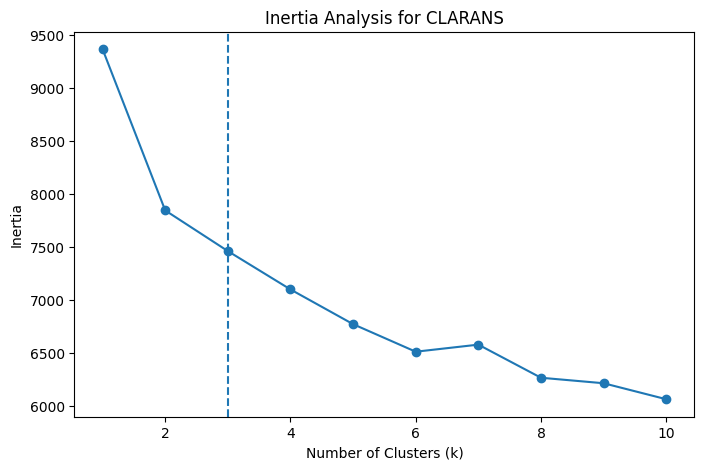

In [49]:
#Chạy để chọn k tốt nhất bằng Inertia
k=[1,2,3,4,5,6,7,8,9,10]
n_local=5
max_nei=20
clarans_Inertia_analysis(data,k,num_local=n_local,max_neighbors=max_nei)

In [50]:
#Chạy để tune tham số
k=3
local_list=[2,5,10,20]
neighbor_list=[5,10,20,50,100,250]
silhouette_scores=[]
davieboudin_scores=[]
params=[]

for local in local_list:
    for neighbor in neighbor_list:
        model = CLARANS(data, k, local, neighbor)
        model.fit()
        labels=model.get_labels()

        sihouette_score_=silhouette_score(data,labels)
        silhouette_scores.append(sihouette_score_)

        davieboudin_score_=davies_bouldin_score(data,labels)
        davieboudin_scores.append(davieboudin_score_)

        params.append((local,neighbor))

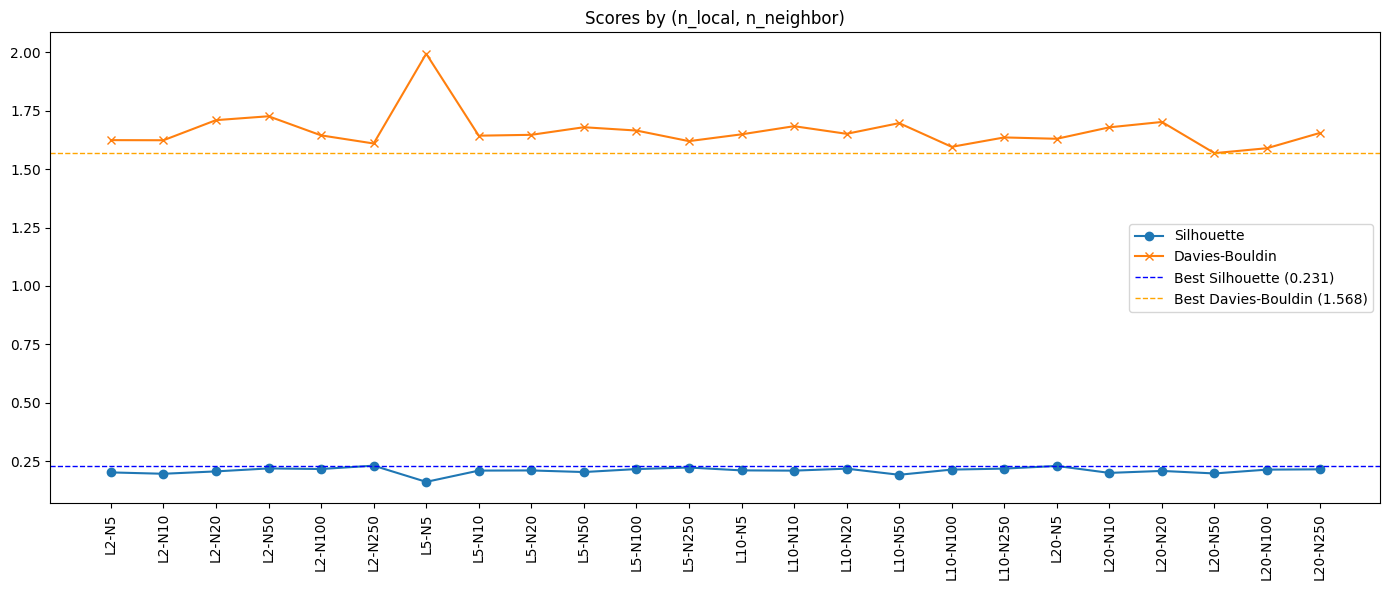

In [51]:
#hiển thị david vs silhouette
labels_x = [f"L{l}-N{n}" for l, n in params]

plt.figure(figsize=(14,6))

plt.plot(silhouette_scores, marker='o', label='Silhouette')
plt.plot(davieboudin_scores, marker='x', label='Davies-Bouldin')

best_sil = max(silhouette_scores)
plt.axhline(y=best_sil, color='blue', linestyle='--', linewidth=1,
            label=f'Best Silhouette ({best_sil:.3f})')
best_db = min(davieboudin_scores)
plt.axhline(y=best_db, color='orange', linestyle='--', linewidth=1,
            label=f'Best Davies-Bouldin ({best_db:.3f})')

plt.xticks(range(len(labels_x)), labels_x, rotation=90)

plt.legend()
plt.title("Scores by (n_local, n_neighbor)")
plt.tight_layout()
plt.show()

TIẾN HÀNH PHÂN CỤM

In [52]:
#xay dung model clarans
k = 3
n_local=5
max_nei=20
Clarans_model = CLARANS(data, k, n_local, max_nei)
(ticks, result) = timedcall(Clarans_model.fit)
print(f"Time taken: {ticks:.4f} seconds")

Time taken: 0.0966 seconds


In [53]:
#lấy cluster và medoids
labels=Clarans_model.get_labels()
medoids = Clarans_model.get_medoids()

print("Labels:", labels)
print("Medoids:", medoids)

Labels: [0 2 0 ... 1 0 2]
Medoids: [[ 0.33223448  1.06418057 -0.89314749  0.44505716  1.22140515  1.12083957
   1.29711817  1.21168776  0.20427439  0.19751163 -0.50464752  2.12623403
   0.35893819  0.48770355  0.98337506  0.68991965]
 [-0.00950556  1.02247465 -0.89314749 -0.65720107  0.98256381  0.97093715
   1.03406959  0.68585426  0.37403653  0.08667404 -0.70237607 -0.03605431
  -0.69656739  1.56084395 -0.25065337 -1.79512893]
 [-0.77842064 -0.63003154 -0.89314749  0.44505716 -1.16788434 -0.8594831
  -1.1389975  -0.56829338  0.03408659 -0.31521282  0.84281514 -0.75681709
  -0.1688146  -0.94315031 -0.86766759  0.68991965]]


In [54]:
#gắn nhãn cluster đã có vào df
data['cluster'] = labels
data_before_scaling['cluster']=labels
print('\nKích thước clusters:', Counter(labels))
print('\n2 clusters lớn nhất:', Counter(labels).most_common(2))


Kích thước clusters: Counter({np.int64(2): 1078, np.int64(1): 609, np.int64(0): 542})

2 clusters lớn nhất: [(np.int64(2), 1078), (np.int64(1), 609)]


In [55]:
#luu model
jlb.dump(Clarans_model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [56]:
#load model
Loaded_Clarans_model = jlb.load('../customer_clustering/Output/clarans.mdl')

TRỰC QUAN HOÁ KẾT QUẢ

Quan sát trước với biểu đồ PCA

In [57]:
pal = ["#2ca02c", "#ff7f0e", "#1f77b4"]

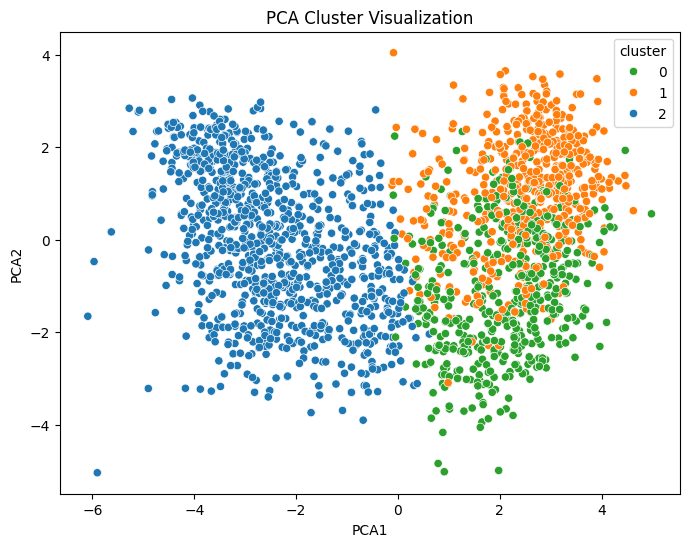

In [58]:
pca=PCA(n_components=2)
pca.fit(data)
PCA_ds=pd.DataFrame(pca.transform(data),columns=(['col1','col2']))

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=PCA_ds['col1'],
    y=PCA_ds['col2'],
    hue=data['cluster'],
    palette=pal
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title('PCA Cluster Visualization')
plt.show()

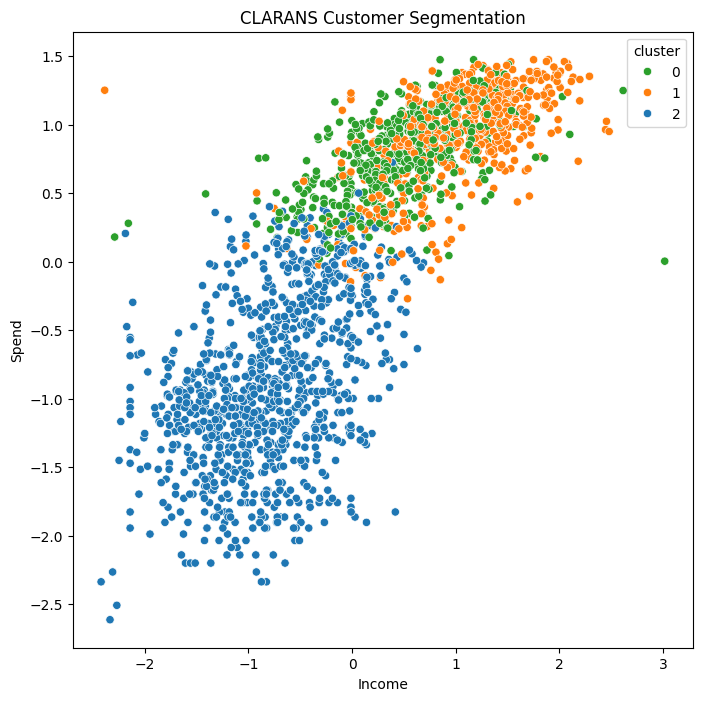

In [59]:
#Phân cụm thể hiện theo income và spend

plt.figure(figsize=(8,8))

sns.scatterplot(x=data['Income'],
            y=data['Total_Spend'],
            hue=data['cluster'],palette=pal)

plt.xlabel("Income")
plt.ylabel("Spend")
plt.title("CLARANS Customer Segmentation")

plt.show()

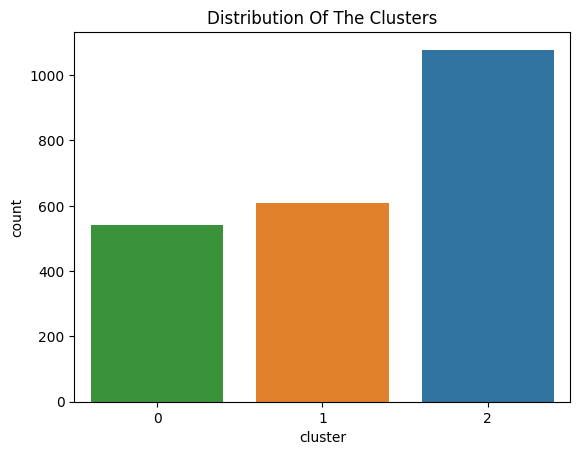

In [60]:
#Quan sát phân phối của từng cụm
pl = sns.countplot(x=data["cluster"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

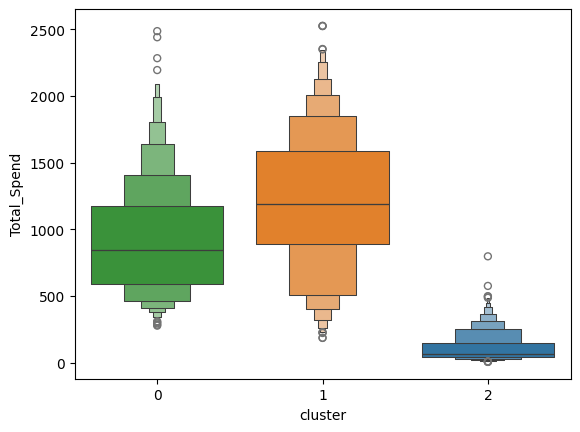

In [66]:
#quan sát tổng chi của mỗi cluster
plt.figure()
pl=sns.boxenplot(x=data_before_scaling["cluster"], y=data_before_scaling["Total_Spend"], palette=pal)
plt.show()

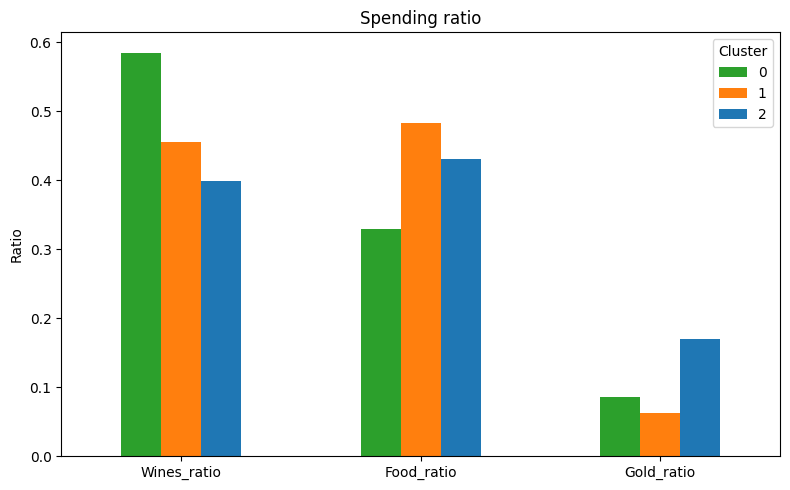

In [77]:
cluster_means = data_before_scaling.groupby('cluster')[['Wines_ratio', 'Food_ratio', 'Gold_ratio']].mean()

cluster_means.T.plot(kind='bar', figsize=(8,5), color=pal,rot=0)
plt.title('Spending ratio')
plt.ylabel('Ratio')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

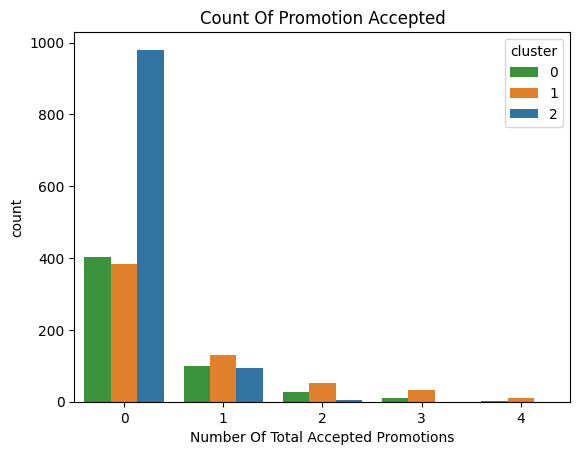

In [ ]:
data_before_scaling["Total_Promo"] = data_before_scaling["AcceptedCmp1"]+ data_before_scaling["AcceptedCmp2"]+ data_before_scaling["AcceptedCmp3"]+ data_before_scaling["AcceptedCmp4"]+ data_before_scaling["AcceptedCmp5"]

plt.figure()
pl = sns.countplot(x=data_before_scaling["Total_Promo"],hue=data_before_scaling["cluster"], palette= pal)
pl.set_title("Count Of Promotion Accepted")
pl.set_xlabel("Number Of Total Accepted Promotions")
plt.show()

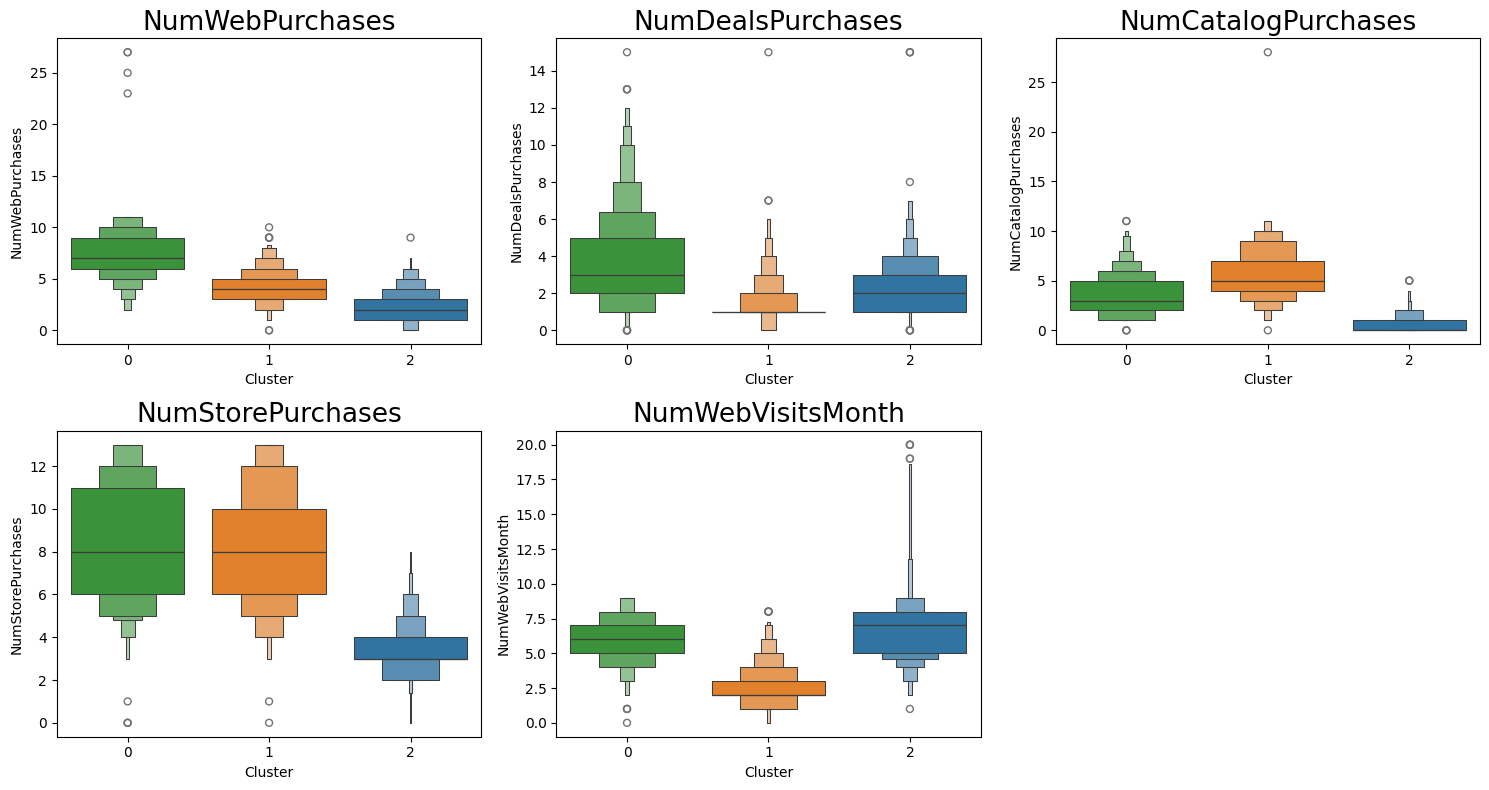

In [84]:
# Quan sát cluster với kênh mua hàng
f = ['NumWebPurchases', 'NumDealsPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

fig = plt.figure(figsize=(15, 8))
for i in range(3):
    ax = fig.add_subplot(2, 3, i+1)
    sns.boxenplot(y=data_before_scaling[f[i]], x=data_before_scaling["cluster"], 
                  palette=pal, ax=ax)
    ax.set_title(f[i],fontsize=19)
    ax.set_xlabel('Cluster')
for i in range(2):
    ax = fig.add_subplot(2, 3, 4+i) 
    sns.boxenplot(y=data_before_scaling[f[3+i]], x=data_before_scaling["cluster"], 
                  palette=pal, ax=ax)
    ax.set_title(f[3+i],fontsize=19)
    ax.set_xlabel('Cluster')

fig.add_subplot(2, 3, 6).set_visible(False)
plt.tight_layout()
plt.show()

PROFILING

Sau khi phân cụm ta sẽ tiến hành quan sát từng đối tượng trong cụm đó là những ai

<Figure size 640x480 with 0 Axes>

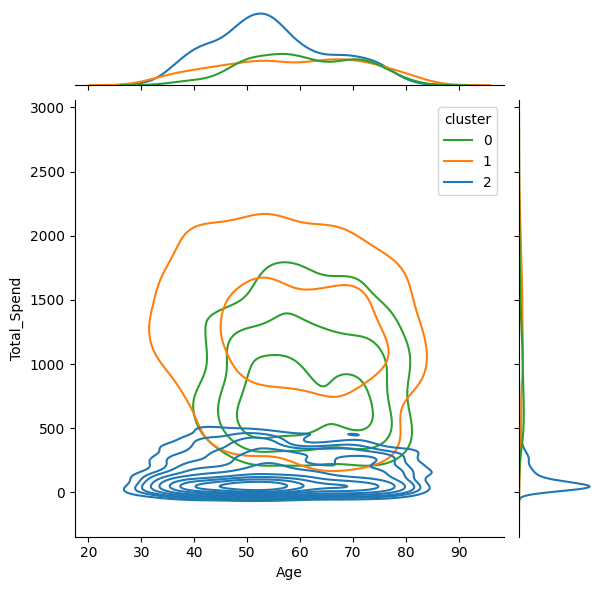

<Figure size 640x480 with 0 Axes>

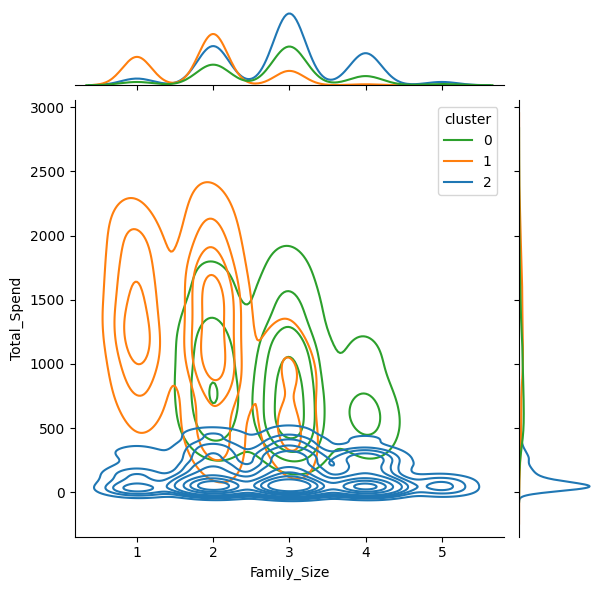

<Figure size 640x480 with 0 Axes>

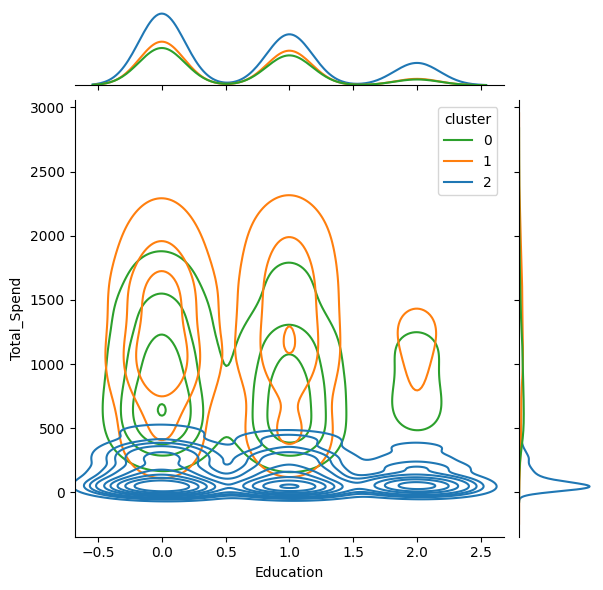

In [87]:
Personal = ["Age","Family_Size","Education"]

for i in Personal:
    plt.figure()
    sns.jointplot(x=data_before_scaling[i], y=data_before_scaling["Total_Spend"], hue =data_before_scaling["cluster"], kind="kde", palette=pal)
    plt.show()